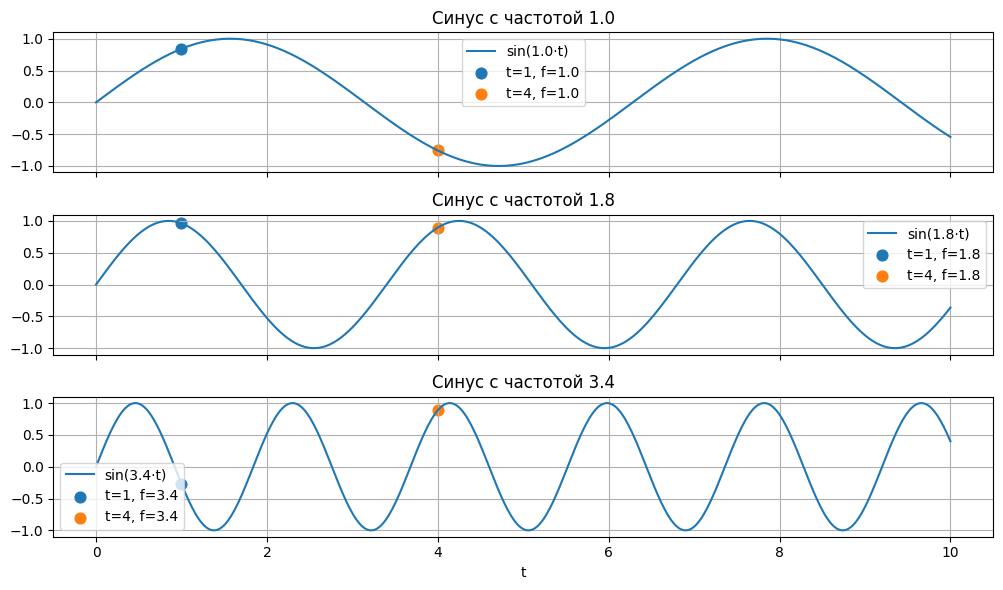

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from disk_analyzer.models.Net import FourierTimeEncoding

DIM = 32
MAX_T = 10
T_VALUES = [1, 4]
encoder = FourierTimeEncoding(dim=DIM)

freqs = encoder.freqs[:3].numpy()
t_plot = torch.linspace(0, MAX_T, 500).numpy()

fig, axes = plt.subplots(len(freqs), 1, figsize=(10, 2*len(freqs)), sharex=True)

for i, (ax, f) in enumerate(zip(axes, freqs)):
    ax.plot(t_plot, np.sin(f * t_plot), label=f"sin({f:.1f}·t)")
    

    for t in T_VALUES:
        y = np.sin(f * t)
        ax.scatter([t], [y], s=60, label=f"t={t}, f={f:.1f}")
    
    ax.set_title(f"Синус с частотой {f:.1f}")
    ax.legend()
    ax.grid(True)

axes[-1].set_xlabel("t")
plt.tight_layout()
plt.show()


In [28]:
import pickle
with open('Artifacts/Exp_46/models/4_SP_model.pkl', 'rb') as f:
    model = pickle.load(f)

In [29]:
model._model.module.net[7].beta

Parameter containing:
tensor(0.9992, device='cuda:0', requires_grad=True)